# 05 — Ruido gaussiano en el sinograma

## Objetivo

Estudiar la distribución realmente añadida en las ramas del experimento principal.

**Alcance:** Hito 1 actualizado.

## Datos utilizados

Par TCIA C095/1-250 de `config/default.json`. Las rutas DICOM se configuran en ese JSON; por defecto se usan data/sdct y data/ldct. Cada notebook se ejecuta de forma independiente.

## Procedimiento

Generar los sinogramas y dos realizaciones independientes con SeedSequence(42).spawn(2). Restar sinograma ruidoso − original para aislar el ruido añadido y medir su media y sigma.

**Procedencia:** sdct_ldct_sinograma_gaussiano.ipynb, celda 18; ldct/noise/gaussian.py; histogram_values de utils_functions.py; detalles en `../REFACTOR_MAP.md`.

## Parámetros

In [1]:
from pathlib import Path
import os
import sys
sys.dont_write_bytecode = True
start = Path.cwd().resolve()
root = next((p for p in (start, *start.parents) if (p / 'src/config.py').is_file() and (p / 'config/default.json').is_file()), None)
if root is None and (start / 'hito1-mini-tesis/src').is_dir():
    root = start / 'hito1-mini-tesis'
if root is None:
    raise RuntimeError('Abre Jupyter desde la raíz del repositorio o su carpeta notebooks.')
sys.path.insert(0, str(root))
os.environ['MPLCONFIGDIR'] = str(root / 'outputs/.matplotlib')
import numpy as np
import matplotlib.pyplot as plt
from src.config import load_config, output_path
from src.experiments import prepare_pair
from src.io import save_table
from src.visualization import show_table, finish_figure
config = load_config()
show_table([{key: config[key] for key in ('num_angles', 'sigma_gaussian', 'seed', 'filter_name', 'visual_amplification')}])

num_angles,sigma_gaussian,seed,filter_name,visual_amplification
512,1,42,ramp,5


## Resultados

In [2]:
from src.experiments import gaussian_conditions, reconstruct_conditions
pair = prepare_pair(config)
conditions = gaussian_conditions(pair, config)
residuals = [conditions[i + 2]['sinogram'] - conditions[i]['sinogram'] for i in (0, 1)]
rows = [dict(imagen=label, media=float(error.mean()), sigma_empirica=float(error.std()),
             sigma_configurada=config['sigma_gaussian'], n_muestras=error.size)
        for label, error in zip(('SDCT', 'LDCT'), residuals)]
show_table(rows)
save_table(rows, output_path('tables', '05_noise_statistics.csv'))

imagen,media,sigma_empirica,sigma_configurada,n_muestras
SDCT,0.00119767,0.997981,1,371200
LDCT,0.000403876,1.00063,1,371200


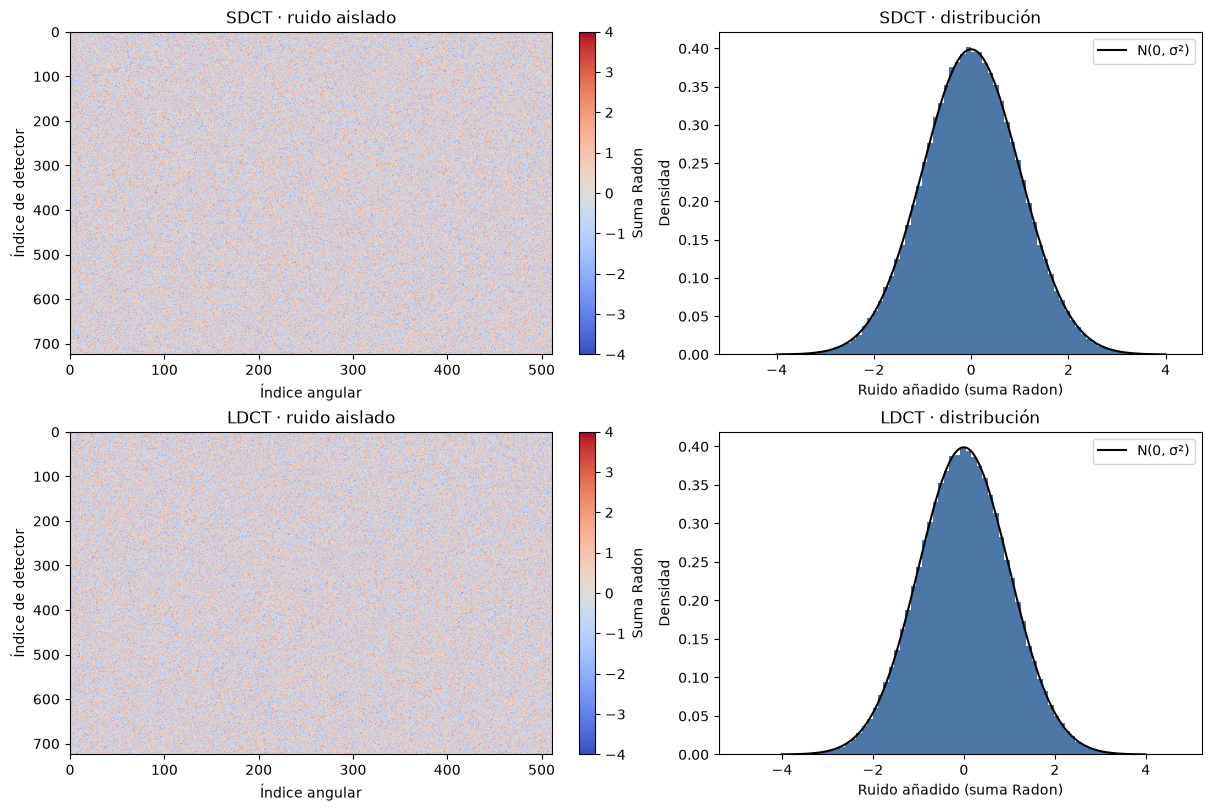

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout='constrained')
sigma = config['sigma_gaussian']
limit = max(4 * sigma, np.finfo(float).eps)
for row, (label, residual) in enumerate(zip(('SDCT', 'LDCT'), residuals)):
    im = axes[row, 0].imshow(residual, cmap='coolwarm', vmin=-limit, vmax=limit, aspect='auto')
    axes[row, 0].set(title=label + ' · ruido aislado', xlabel='Índice angular', ylabel='Índice de detector')
    fig.colorbar(im, ax=axes[row, 0], label='Suma Radon')
    axes[row, 1].hist(residual.ravel(), bins=80, density=True, color='#4c78a8')
    if sigma > 0:
        x = np.linspace(-limit, limit, 300)
        axes[row, 1].plot(x, np.exp(-0.5 * (x / sigma)**2) / (sigma * np.sqrt(2 * np.pi)), color='black', label='N(0, σ²)')
        axes[row, 1].legend()
    axes[row, 1].set(xlabel='Ruido añadido (suma Radon)', ylabel='Densidad', title=label + ' · distribución')
finish_figure(fig, output_path('figures', '05_noise_distribution.png'))

Sigma es desviación estándar en suma Radon, no varianza, HU ni mAs. El histograma analiza los mismos arrays usados en las reconstrucciones; no genera muestras nuevas.

In [4]:
cases = reconstruct_conditions(pair, conditions, config['filter_name'])
show_table([{'case': c['case'], 'RMSE_HU': c['RMSE_HU']} for c in cases])
if sigma == 0:
    np.testing.assert_array_equal(cases[0]['reconstruction'], cases[2]['reconstruction'])
    np.testing.assert_array_equal(cases[1]['reconstruction'], cases[3]['reconstruction'])

case,RMSE_HU
sdct_sin_ruido,31.8897
ldct_sin_ruido,68.8989
sdct_gaussiano,78.9061
ldct_gaussiano,99.7


## Observaciones

El sigma empírico se aproxima al configurado por el gran número de muestras. La LDCT de entrada conserva su ruido y recibe ruido adicional en su rama gaussiana. Esta degradación post-Radon no se convierte a dosis física ni reemplaza el modelo de fotones.